# 1. Wstęp

Transformacja energetyczna, w Niemczech znana jako *Energiewende*, jest jednym z najbardziej złożonych procesów gospodarczych XXI wieku. Polega ona na fundamentalnej przebudowie sektora – odchodzeniu od paliw kopalnych i energetyki jądrowej na rzecz odnawialnych źródeł energii (OZE). Proces ten jest wielowymiarowy i nie da się go opisać za pomocą jednej zmiennej, takiej jak sama produkcja energii z wiatru czy cena giełdowa. Inwestorzy, analitycy oraz decydenci polityczni potrzebują zagregowanego, syntetycznego miernika, który – na wzór Produktu Krajowego Brutto dla gospodarki – pozwoli w jednej liczbie uchwycić ogólną kondycję i postęp tej transformacji.

Celem niniejszego projektu jest zaprojektowanie, zbudowanie i prognozowanie takiego syntetycznego wskaźnika rozwoju dla niemieckiego sektora energetycznego. Analiza opiera się na publicznie dostępnych danych z europejskiej platformy ENTSO-E oraz niemieckiej platformy SMARD.

Główne cele badawcze projektu są następujące:

1.  Wybór i uzasadnienie kluczowych zmiennych diagnostycznych opisujących niemiecki rynek energii (m.in. udział OZE, ceny rynkowe, stabilność systemu).
2.  Budowa trzech wariantów syntetycznego wskaźnika przy użyciu metod ważenia: równej wagi (EW), analizy składowych głównych (PCA) oraz metody wag entropowych (EWM).
3.  Zaprojektowanie i testowanie dwóch fundamentalnie różnych podejść do prognozowania wskaźnika na okres dwóch lat.
4.  Porównanie skuteczności obu strategii prognostycznych przy użyciu miar błędu ex-post, w tym RMSPE i współczynnika Theila.

Praca przedstawia metodykę pozyskania i agregacji danych, konstrukcję wskaźników oraz szczegółową analizę porównawczą wyników prognoz, kończąc na wnioskach dla sektora.


# 2. Źródła danych i metodyka badawcza

Badanie opiera się na danych wtórnych pozyskanych z oficjalnych platform monitorujących europejski rynek energii. Proces badawczy obejmował ekstrakcję danych surowych, ich transformację (ETL), konstrukcję zmiennych diagnostycznych oraz budowę modeli prognostycznych.

## 2.1. Charakterystyka źródeł danych

Głównym źródłem danych jest **ENTSO-E Transparency Platform** (European Network of Transmission System Operators for Electricity). Jest to centralne repozytorium danych dla europejskiego rynku energii elektrycznej, funkcjonujące na mocy Rozporządzenia Komisji (UE) nr 543/2013. Platforma zapewnia dostęp do danych o generacji, obciążeniu i cenach w wysokiej rozdzielczości czasowej (15-60 minut).

Jako źródło uzupełniające i weryfikacyjne wykorzystano platformę **SMARD**, prowadzoną przez niemieckiego regulatora (Bundesnetzagentur). SMARD agreguje dane z ENTSO-E, zapewniając ich walidację i przejrzystą strukturę dla rynku niemieckiego.

Zakres czasowy badania obejmuje okres od **stycznia 2015 r.** (początek pełnego raportowania ENTSO-E) do **października 2025 r.**, co daje łącznie 130 obserwacji miesięcznych.

## 2.2. Zmienne diagnostyczne

Na podstawie literatury przedmiotu wyselekcjonowano zestaw 6 zmiennych diagnostycznych, opisujących kluczowe wymiary rozwoju sektora:

1.  **Udział OZE (`res_share`):** Stosunek generacji ze źródeł odnawialnych (wiatr, słońce, woda, biomasa) do generacji całkowitej. Jest to stymulanta (wzrost oznacza postęp transformacji).
2.  **Udział paliw kopalnych (`fossil_share`):** Stosunek generacji z węgla, gazu i ropy do generacji całkowitej.Jest to destymulanta (pożądany jest spadek).
3.  **Cena rynkowa (`market_price`):** Średnia cena hurtowa energii elektrycznej na rynku dnia następnego (Day-Ahead Market) wyrażona w EUR/MWh. Traktowana jako destymulanta (wzrost ceny obniża konkurencyjność gospodarki).
4.  **Zmienność cen (`price_volatility`):** Odchylenie standardowe cen godzinowych w danym miesiącu. Mierzy ryzyko rynkowe i niepewność (destymulanta).
5.  **Całkowite zużycie (`energy_consumption`):** Sumaryczny wolumen energii zużytej w gospodarce (MWh). Wskaźnik skali rynku (stymulanta).
6.  **Stabilność systemu (`system_stability`):** Mierzona jako średni procentowy błąd prognozy zapotrzebowania operatora (MAPE). Niższy błąd oznacza wyższą stabilność i przewidywalność systemu (destymulanta).

## 2.3. Przygotowanie i agregacja danych (ETL)

Proces przygotowania danych został zrealizowany w środowisku Python przy użyciu biblioteki `entsoe-py`. Kluczowe etapy obejmowały:

-   **Unifikacja stref cenowych:** Uwzględniono historyczny podział strefy cenowej DE-AT-LU (Niemcy-Austria-Luksemburg), który nastąpił 1 października 2018 r. Dane sprzed tej daty dla strefy połączonej zostały scalone z danymi dla strefy DE-LU (Niemcy-Luksemburg).
-   **Agregacja czasowa:** Dane surowe o granularności 15-minutowej (obciążenie) i godzinowej (ceny) zostały zagregowane do częstotliwości miesięcznej (`ME`). Zastosowano sumowanie dla wolumenów (MWh) oraz średnią dla cen i wskaźników procentowych.
-   **Flaga kryzysowa:** Utworzono binarną zmienną pomocniczą `crisis_flag`, przyjmującą wartość 1 dla okresów pandemii COVID-19 (03.2020–06.2021) oraz kryzysu energetycznego (09.2021–12.2023).

## 2.4. Metody konstrukcji wskaźnika syntetycznego

W celu zbudowania syntetycznego miernika rozwoju (SMR) zastosowano procedurę unitaryzacji zerowanej (standaryzacja Z-Score), sprowadzającą zmienne do porównywalności. Następnie obliczono trzy warianty wskaźnika:

1.  **Metoda Równych Wag (EW):** Średnia arytmetyczna ze wszystkich unormowanych zmiennych. Zakłada jednakowy wpływ każdego czynnika na rozwój sektora.
2.  **Analiza Składowych Głównych (PCA):** Metoda redukcji wymiaru, w której wagi wyznaczane są na podstawie ładunków pierwszej składowej głównej, wyjaśniającej największą część wariancji zbioru danych.
3.  **Metoda Wag Entropowych (EWM):** Podejście obiektywne, w którym wagi zależą od stopnia nieuporządkowania informacji (entropii). Zmienne o większej zmienności otrzymują wyższe wagi, jako niosące więcej unikalnej informacji.

## 2.5. Metodyka prognozowania

Badanie porównuje dwie strategie prognostyczne dla horyzontu 24 miesięcy: \* **Podejście bezpośrednie:** Prognozowanie finalnego indeksu syntetycznego. \* **Podejście pośrednie (agregacja):** Prognozowanie każdego składnika z osobna, a następnie ich scalenie w indeks.

W podejściu bezpośrednim do prognozowania syntetycznych wskaźników zastosowano zestaw modeli klasycznych, a następnie wybrano te, które zapewniały najniższe błędy ex‑post na zbiorze testowym (ostatnie 24 miesiące). Dla indeksu EW oraz PCA najlepsze dopasowanie uzyskano przy użyciu modelu **Holt‑Winters**, natomiast dla indeksu EWM – modelu **ETS**. Jakość prognoz oceniono przy użyciu pełnego zestawu miar trafności: **ME** (średni błąd), **MPE** (średni błąd procentowy), **MAE** (średni błąd bezwzględny), **MAPE** (średni błąd procentowy bezwzględny), **RMSE** (pierwiastek błędu średniokwadratowego), **RMSPE** (względny błąd średniokwadratowy) oraz **współczynnika Theila**.

# 3. Analiza i Wyniki

W niniejszym rozdziale przedstawiono wyniki analizy empirycznej. Proces badawczy podzielono na trzy etapy: wstępną eksplorację danych (EDA), konstrukcję wskaźników syntetycznych oraz modelowanie prognostyczne.


## 3.1. Wstępna analiza danych (EDA)

Pierwszym krokiem jest wczytanie przygotowanych danych miesięcznych oraz analiza ich podstawowych statystyk opisowych. Pozwala to na weryfikację poprawności danych oraz identyfikację ogólnych charakterystyk badanego okresu (2015–2025).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Konfiguracja stylu
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper")

# --- WCZYTANIE DANYCH ---

filename = "dane_miesieczne_DE.csv"
folder = "dane_po_transformacji"
path_in_folder = os.path.join(folder, filename)

if os.path.exists(path_in_folder):
    file_path = path_in_folder
elif os.path.exists(filename):
    file_path = filename
else:
    raise FileNotFoundError(f"Nie znaleziono pliku {filename}")

df = pd.read_csv(file_path)
# Parsowanie daty (format pełny z CSV)
df['date_dt'] = pd.to_datetime(df['date'], utc=True)
df = df.set_index('date_dt')

diagnostic_vars = [
    'res_share', 'fossil_share', 'market_price', 
    'price_volatility', 'energy_consumption', 'system_stability'
]

# --- PRZYGOTOWANIE TABELI STATYSTYK ---
df_display = df[diagnostic_vars].copy()

# Konwersja Energy Consumption z MWh na TWh
df_display['energy_consumption'] = df_display['energy_consumption'] / 1_000_000

# Obliczanie statystyk
stats = df_display.describe().T
stats = stats[['mean', 'std', 'min', '50%', 'max']]

# Dodanie Współczynnika Zmienności (Coefficient of Variation) w %
stats['CV (%)'] = (stats['std'] / stats['mean']) * 100

# Zmiana nazw kolumn na polskie
stats.columns = ['Średnia', 'Odchylenie Std.', 'Min', 'Mediana', 'Max', 'Zmienność (CV %)']

# Mapowanie nazw zmiennych
variable_names = {
    'res_share': 'Udział OZE (ułamek)',
    'fossil_share': 'Udział Paliw Kopalnych (ułamek)',
    'market_price': 'Cena Rynkowa [EUR/MWh]',
    'price_volatility': 'Zmienność Cen (wew. miesiąca)',
    'energy_consumption': 'Zużycie Energii [TWh]',
    'system_stability': 'Błąd Prognozy MAPE (Stabilność)'
}
stats = stats.rename(index=variable_names)

# Wyświetlenie tabeli
print(stats.to_markdown(floatfmt=".4f"))

|                                 |   Średnia |   Odchylenie Std. |     Min |   Mediana |      Max |   Zmienność (CV %) |
|:--------------------------------|----------:|------------------:|--------:|----------:|---------:|-------------------:|
| Udział OZE (ułamek)             |    0.2582 |            0.0494 |  0.1544 |    0.2511 |   0.3906 |            19.1111 |
| Udział Paliw Kopalnych (ułamek) |    0.2145 |            0.0374 |  0.1087 |    0.2177 |   0.3034 |            17.4419 |
| Cena Rynkowa [EUR/MWh]          |   72.5437 |           67.7652 | 17.0492 |   47.6461 | 465.5142 |            93.4129 |
| Zmienność Cen (wew. miesiąca)   |   32.7877 |           30.5995 |  5.8554 |   19.5137 | 156.2992 |            93.3261 |
| Zużycie Energii [TWh]           |   40.7558 |            2.8643 | 35.2141 |   40.5780 |  47.4162 |             7.0280 |
| Błąd Prognozy MAPE (Stabilność) |    0.0417 |            0.0151 |  0.0195 |    0.0385 |   0.0962 |            36.3449 |


Średni udział OZE i paliw kopalnych w miksie wytwórczym jest relatywnie stabilny, co wskazuje na brak gwałtownych zmian w strukturze źródeł energii. Jednocześnie zmienne cenowe – zarówno poziom cen, jak i ich wewnątrzmiesięczna zmienność – cechują się bardzo wysoką niestabilnością, co odzwierciedla epizodyczne skoki i podwyższone ryzyko na rynku energii elektrycznej. Zużycie energii pozostaje stosunkowo stabilne, a przeciętny błąd prognozy MAPE na poziomie ok. 4% sugeruje ogólnie dobrą, choć nie w pełni równomierną w czasie, jakość modeli prognostycznych.

## 3.1.1. Wizualizacja szeregów czasowych

Wizualizacja przebiegu zmiennych w czasie pozwala zidentyfikować trendy, sezonowość oraz wpływ szoków zewnętrznych. Na wykresach poniżej zacieniowano okresy kryzysowe:

Szary obszar: Pandemia COVID-19 (03.2020 – 06.2021).

Czerwony obszar: Kryzys energetyczny i wojna w Ukrainie (09.2021 – 12.2023).

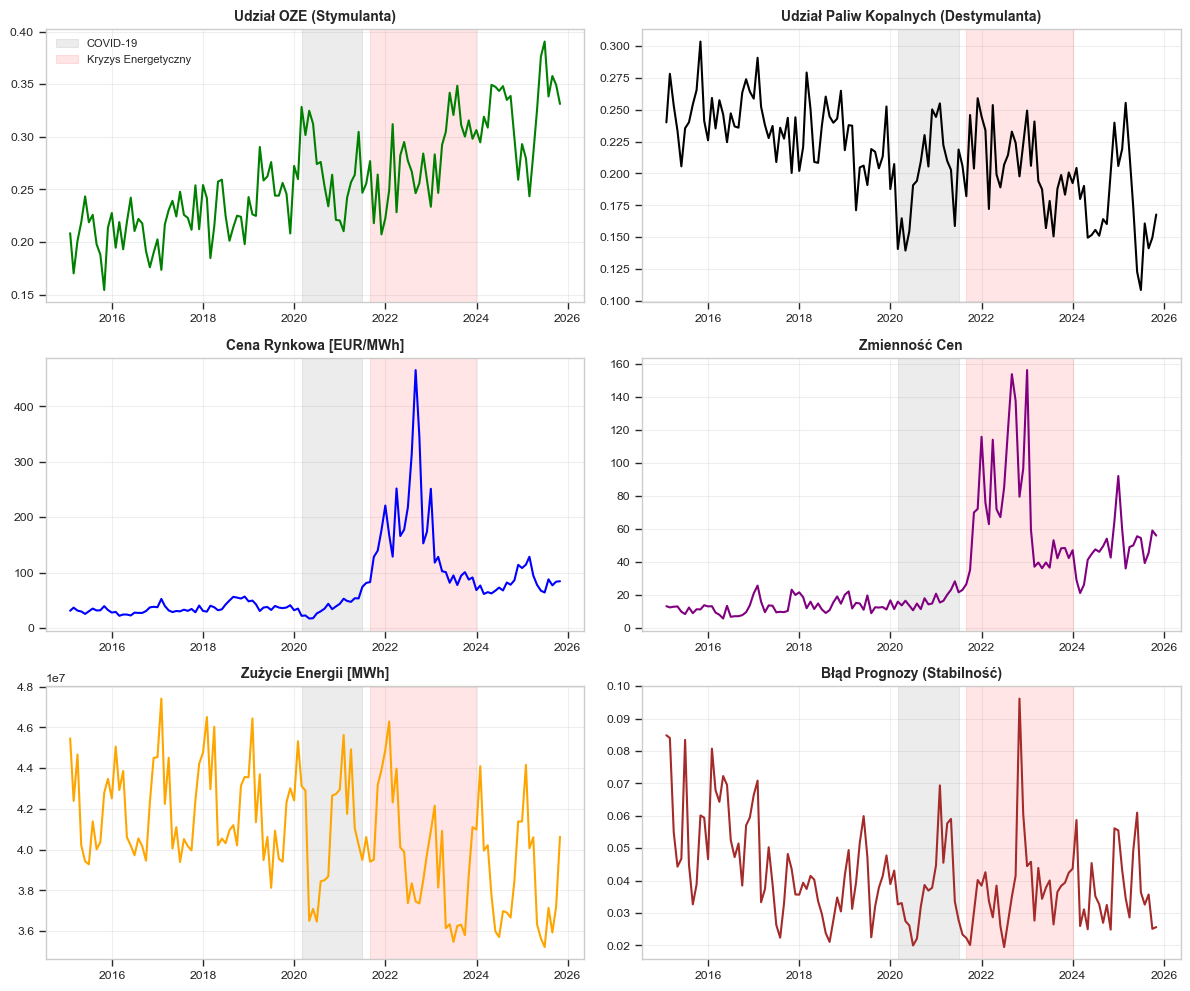

In [4]:
#| label: wizualizacja-szeregow
#| echo: false
#| fig-cap: "Przebieg zmiennych diagnostycznych w latach 2015-2025."
#| fig-height: 10
#| warning: false

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

# Słownik tytułów dla lepszej czytelności
titles = {
    'res_share': 'Udział OZE (Stymulanta)',
    'fossil_share': 'Udział Paliw Kopalnych (Destymulanta)',
    'market_price': 'Cena Rynkowa [EUR/MWh]',
    'price_volatility': 'Zmienność Cen',
    'energy_consumption': 'Zużycie Energii [MWh]',
    'system_stability': 'Błąd Prognozy (Stabilność)'
}

colors = ['green', 'black', 'blue', 'purple', 'orange', 'brown']

for i, col in enumerate(diagnostic_vars):
    ax = axes[i]
    ax.plot(df.index, df[col], color=colors[i], linewidth=1.5)
    ax.set_title(titles.get(col, col), fontsize=10, fontweight='bold')
    
    # Oznaczenie kryzysów
    ax.axvspan('2020-03-01', '2021-06-30', color='gray', alpha=0.15, label='COVID-19')
    ax.axvspan('2021-09-01', '2023-12-31', color='red', alpha=0.10, label='Kryzys Energetyczny')
    
    ax.grid(True, alpha=0.3)
    
    # Legenda tylko dla pierwszego wykresu
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

Analiza wizualna szeregów czasowych pozwala na sformułowanie trzech kluczowych wniosków dotyczących dynamiki niemieckiego rynku energii w badanym okresie:

Strukturalna transformacja miksu energetycznego: Zmienne Udział OZE oraz Udział Paliw Kopalnych wykazują wyraźny, długoterminowy trend deterministyczny. Obserwujemy systematyczny wzrost znaczenia źródeł odnawialnych przy jednoczesnym spadku generacji konwencjonalnej. Zjawisko to potwierdza postępującą realizację celów Energiewende, choć widoczna jest silna sezonowość wynikająca z warunków pogodowych (wietrzność i nasłonecznienie).

Wpływ szoków egzogenicznych na ceny: Przebieg zmiennej Cena Rynkowa oraz Zmienność Cen wskazuje na wystąpienie ekstremalnej anomalii w latach 2021–2022 (obszar zacieniowany na czerwono). Wzrost cen do poziomów przekraczających 400 EUR/MWh nie wynikał z cykli koniunkturalnych, lecz był skutkiem szoku podażowego (kryzys gazowy i wojna w Ukrainie). Wcześniejszy okres pandemii COVID-19 (obszar szary) charakteryzował się z kolei presją deflacyjną na ceny energii.

Stabilność popytu a zmienność rynku: Zmienna Zużycie Energii wykazuje wysoką stabilność i silną sezonowość roczną, z jedynie niewielkim załamaniem w pierwszej fazie pandemii. Kontrastuje to z gigantyczną zmiennością strony cenowej. Oznacza to, że rynek energii w Niemczech jest sztywny popytowo – drastyczne zmiany cen w niewielkim stopniu przekładają się na natychmiastową redukcję konsumpcji.

## 3.1.2. Mapa ciepła korelacji

Opis: W tej sekcji należy przedstawić macierz korelacji Pearsona dla zmiennych diagnostycznych. Celem jest identyfikacja siły i kierunku powiązań między zmiennymi (np. czy wzrost udziału OZE faktycznie wiąże się ze spadkiem emisji paliw kopalnych). Jest to kluczowy krok uzasadniający użycie metody PCA, która redukuje wymiarowość silnie skorelowanych danych. Należy również zweryfikować, czy zmienne nie są ze sobą tożsame (korelacja bliska 1 lub -1).

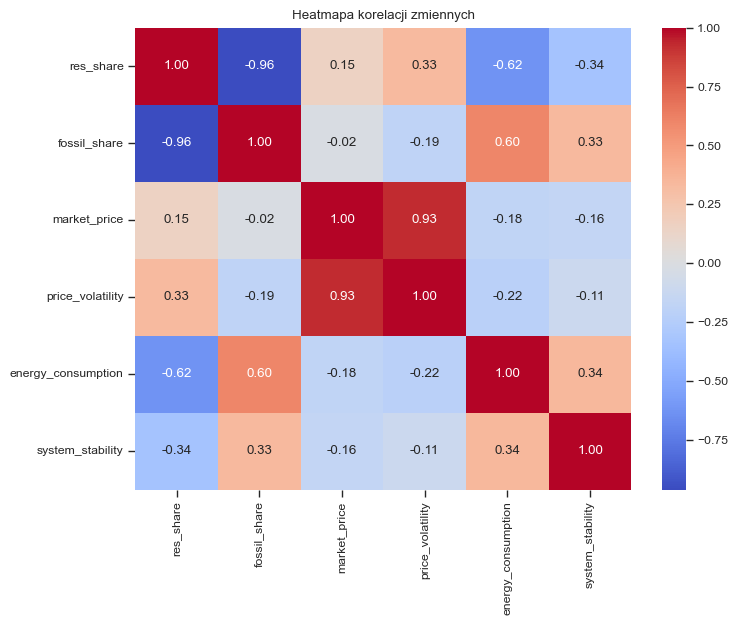

In [5]:
# --HEATMAPA--

import seaborn as sns
df_heatmapa = df[diagnostic_vars]
plt.figure(figsize=(8,6))
corr = df_heatmapa.corr()  
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmapa korelacji zmiennych")
plt.show()

Najbardziej fundamentalną zależnością, widoczną na pierwszy rzut oka, jest niemal idealna ujemna korelacja ($r = -0.96$) pomiędzy udziałem źródeł odnawialnych (**res_share**) a udziałem paliw kopalnych (**fossil_share**). Oznacza to, że wzrost generacji z OZE niemal automatycznie i proporcjonalnie skutkuje redukcją produkcji z elektrowni konwencjonalnych. Jest to dowód na bezpośrednie wypieranie energetyki konwencjonalnej przez źródła odnawialne.

Drugim istotnym wnioskiem jest bardzo silna korelacja dodatnia ($r = 0.93$) łącząca cenę rynkową (**market_price**) z jej zmiennością (**price_volatility**). Oznacza to, że okresy drogiej energii nie są stabilne – wysokim cenom towarzyszą gwałtowne wahania (skoki cenowe). Wskazuje to, że szoki cenowe (np. kryzys energetyczny 2021-2022) destabilizują rynek, czyniąc go nieprzewidywalnym dla uczestników.

Interesujące zależności ujawnia również analiza całkowitego zużycia energii (**energy_consumption**). Zmienna ta jest dodatnio skorelowana z udziałem paliw kopalnych ($0.60$) i ujemnie z udziałem OZE ($-0.62$). Wynika to z charakterystyki sezonowej: najwyższe zapotrzebowanie na energię w Niemczech występuje zimą, kiedy generacja słoneczna (kluczowy składnik OZE) jest minimalna, a system musi być bilansowany przez sterowalne elektrownie węglowe i gazowe.

Ciekawym spostrzeżeniem jest brak istotnej korelacji liniowej pomiędzy ceną energii (**market_price**) a strukturą produkcji ($fossil_share: -0.02$, $res_share: 0.15$). Wskazuje to, że ceny hurtowe w badanym okresie były determinowane głównie przez czynniki zewnętrzne i geopolityczne (np. globalne ceny surowców), a nie przez lokalny udział wiatru czy węgla w systemie. Potwierdza to słuszność uwzględnienia ceny jako osobnej, niezależnej zmiennej diagnostycznej, gdyż niesie ona zupełnie inne informacje niż dane o produkcji

## 3.2. Konstrukcja i analiza wskaźników syntetycznych

Opis: Sekcja ta opisuje proces transformacji surowych zmiennych w gotowe indeksy. Należy przeprowadzić standaryzację zmiennych (Z-Score) w celu doprowadzenia ich do porównywalności. Następnie, na bazie ujednoliconych danych, należy obliczyć trzy warianty wskaźnika:

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
# --Stymulanty + Destymulanty--

# kopia żeby nie psuć oryginału

X = df[diagnostic_vars].copy()

# Destymulanty
# - fossil_share (chcemy mniej)
# - market_price (dla konsumenta niższa cena = lepiej)
# - price_volatility (stabilność = lepiej)
# - system_stability (mniejszy błąd = lepiej)
destymulanty = ['fossil_share', 'market_price', 'price_volatility', 'system_stability']

# zamiana destymulant na stymulanty przez mnożenie * -1
for col in destymulanty:
    X[col] = -X[col]


# --STANDARYZACJA--

scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns, index=X.index)
print('\nPrzykładowe wiersze po standaryzacji:')
print(X_std.head())


Przykładowe wiersze po standaryzacji:
                           res_share  fossil_share  market_price  \
date_dt                                                            
2015-01-31 00:00:00+00:00  -1.013839     -0.685127      0.614731   
2015-02-28 00:00:00+00:00  -1.790278     -1.706724      0.531073   
2015-03-31 00:00:00+00:00  -1.159472     -1.037430      0.611014   
2015-04-30 00:00:00+00:00  -0.802776     -0.507492      0.633520   
2015-05-31 00:00:00+00:00  -0.301864      0.239538      0.699415   

                           price_volatility  energy_consumption  \
date_dt                                                           
2015-01-31 00:00:00+00:00          0.638386            1.649778   
2015-02-28 00:00:00+00:00          0.662860            0.572529   
2015-03-31 00:00:00+00:00          0.648961            1.371767   
2015-04-30 00:00:00+00:00          0.643928           -0.190924   
2015-05-31 00:00:00+00:00          0.748563           -0.464673   

              

## EW (Equal Weighting): Prosta średnia arytmetyczna.

In [7]:
idx_ew = X_std.mean(axis=1)
print(idx_ew)

date_dt
2015-01-31 00:00:00+00:00   -0.276210
2015-02-28 00:00:00+00:00   -0.755981
2015-03-31 00:00:00+00:00   -0.073053
2015-04-30 00:00:00+00:00   -0.066260
2015-05-31 00:00:00+00:00    0.097734
                               ...   
2025-06-30 00:00:00+00:00    0.559072
2025-07-31 00:00:00+00:00    0.327024
2025-08-31 00:00:00+00:00    0.367849
2025-09-30 00:00:00+00:00    0.402751
2025-10-31 00:00:00+00:00    0.469842
Length: 130, dtype: float64


## PCA (Principal Component Analysis): Wyznaczenie pierwszej składowej głównej, która wyjaśnia największą część wariancji.

In [8]:
pca = PCA(n_components=1)
pca_values = pca.fit_transform(X_std).flatten()
idx_pca = pd.Series(pca_values, index=X.index)



weights_pca = pd.Series(pca.components_[0], index=X_std.columns)
print("Wagi PCA dla zmiennych:")
print(weights_pca)

Wagi PCA dla zmiennych:
res_share             0.526387
fossil_share          0.491728
market_price         -0.278140
price_volatility     -0.340619
energy_consumption   -0.444270
system_stability      0.300601
dtype: float64


## EWM (Entropy Weighting Method): Wyliczenie wag na podstawie entropii Shannona (im większa zmienność danych, tym większa waga). Wynikiem ma być wykres liniowy porównujący przebieg tych trzech indeksów w czasie.

In [9]:
scaler_minmax = MinMaxScaler()
X_norm = pd.DataFrame(scaler_minmax.fit_transform(X), columns=X.columns, index=X.index)

epsilon = 1e-8
P = X_norm / (X_norm.sum(axis=0) + epsilon)
P = np.where(P == 0, epsilon, P) 

k = 1 / np.log(len(X_norm))
E = -k * (P * np.log(P)).sum(axis=0)
d = 1 - E


# Obliczenie wag
weights_ewm = d / d.sum()

idx_ewm = (X_norm * weights_ewm).sum(axis=1)
print("\nWagi EWM:", {col: round(w, 4) for col, w in zip(diagnostic_vars, weights_ewm)})


Wagi EWM: {'res_share': np.float64(0.2473), 'fossil_share': np.float64(0.1956), 'market_price': np.float64(0.0433), 'price_volatility': np.float64(0.0889), 'energy_consumption': np.float64(0.3239), 'system_stability': np.float64(0.1009)}


## Porównanie wskaźników

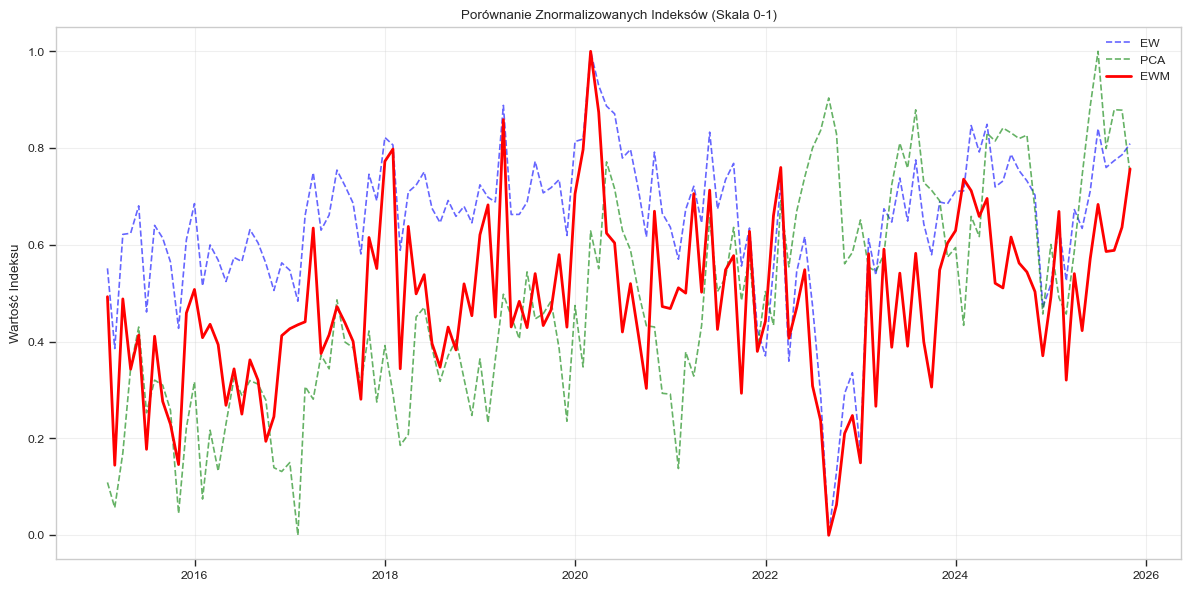

In [10]:
results = pd.DataFrame({
    'EW (Średnia)': idx_ew,
    'PCA (Główna Składowa)': idx_pca,
    'EWM (Entropia)': idx_ewm
}, index=X.index)

# skalowanie osi, bez przeskalowania EWM było bardzo płaskie
results_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(results), 
    columns=results.columns, 
    index=results.index
)

plt.figure(figsize=(12, 6))
plt.plot(results_scaled.index, results_scaled['EW (Średnia)'], label='EW', color='blue', alpha=0.6, linestyle='--')
plt.plot(results_scaled.index, results_scaled['PCA (Główna Składowa)'], label='PCA', color='green', alpha=0.6, linestyle='--')
plt.plot(results_scaled.index, results_scaled['EWM (Entropia)'], label='EWM', color='red', linewidth=2)

plt.title('Porównanie Znormalizowanych Indeksów (Skala 0-1)')
plt.ylabel('Wartość Indeksu')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Wykres przedstawia trzy indeksy (EW, PCA i EWM), które poruszają się w podobnych cyklach, ale różnią się wrażliwością na zmiany. EW jest najbardziej stabilny, utrzymuje się zwykle w przedziale 0.4–0.8 i dobrze oddaje średni poziom analizowanego zjawiska.

PCA cechuje się najwyższą zmiennością. Ponieważ wagi są wyznaczane na podstawie wariancji i struktury korelacji między zmiennymi, wskaźnik ten silnie reaguje na skoki w danych – zwłaszcza w okresach zakłóceń rynkowych. Największe wahania PCA obserwujemy w latach 2015, 2021 oraz 2025, kiedy pojawiały się strukturalne zmiany w miksie energetycznym lub szoki cenowe. PCA odzwierciedla zatem zmienność systemową, a nie tylko poziom rozwoju.

EWM pozostaje między nimi: jest wygładzony, ale nadal wyraźnie reaguje na krótkookresowe zmiany, co widać np. w silnym spadku w 2022 roku i stabilnym wzroście po 2023 roku. Największe różnice między indeksami pojawiają się w okresach podwyższonej zmienności (2021–2022 oraz 2024–2025), kiedy PCA sygnalizuje silne skoki, podczas gdy EW pozostaje stabilny, a EWM reaguje szybciej, lecz z pewnym opóźnieniem. Wspólnie serie pokazują, że mimo tej samej ogólnej dynamiki, każdy indeks uchwyca inną stronę zjawiska: EW – średni trend, EWM – bieżący moment i punkty zwrotne, a PCA – strukturalną zmienność danych.

## 3.3. Podejście 1: Prognoza bezpośrednia indeksu

W tym podejściu traktujemy obliczone wcześniej indeksy syntetyczne (EW, PCA, EWM) jako gotowe szeregi czasowe. Celem jest dopasowanie do nich najlepszego modelu prognostycznego (np. SARIMA lub Holt-Winters) i wygenerowanie prognozy na 24 miesiące do przodu. Należy podzielić zbiór na treningowy i testowy (ostatnie 2 lata), aby sprawdzić jakość modelu.

In [11]:
freq = 'M'  
steps_ahead = 24  
train = idx_ew.iloc[:-steps_ahead]
test = idx_ew.iloc[-steps_ahead:]

print(f'Liczba obserwacji w zbiorze treningowym: {len(train)}')
print(f'Liczba obserwacji w zbiorze testowym: {len(test)}')

Liczba obserwacji w zbiorze treningowym: 106
Liczba obserwacji w zbiorze testowym: 24


Przy 130 obserwacjach miesięcznych modele mają wystarczająco dużo danych, aby uchwycić zarówno trend, jak i sezonowość. Podział na 106 miesięcy treningowych i 24 miesiące testowych pozwala rzetelnie ocenić jakość prognozy.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ocena jakości prognozy 
def eval_metrics(actual, pred):
    me = np.mean(pred - actual)
    mpe = 100*np.mean((pred - actual) / actual)
    mae = np.mean(np.abs(pred - actual))
    mape = 100*np.mean(np.abs((pred - actual) / actual))
    rmse = np.sqrt(np.mean((pred - actual) ** 2))
    rmspe = 100 * (rmse / np.mean(actual)) if np.mean(actual) != 0 else np.nan
    t = np.sqrt(np.mean(((pred[1:] - actual[1:])**2)) / np.mean((actual[1:]**2)))
    return {'ME': me, 'MPE': mpe, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'RMSPE': rmspe, 'Theil': t}

# Wybór najlepszego modelu 
def best_time_model(series, horizon, freq='M'):
    s = series.dropna()
    if freq == 'M':
        s = s.asfreq('ME')
    elif freq == 'Q':
        s = s.asfreq('Q')
    min_rmspe = np.inf
    best_pred = None
    best_str = ''

   
    # 1. OLS trend+sezon
    try:
        X = np.arange(len(s))
        dummies = pd.get_dummies(s.index.month, prefix='M') if freq == 'M' else None
        X_mat = np.column_stack([X, dummies.values]) if dummies is not None else X[:,None]
        model = sm.OLS(s.values, sm.add_constant(X_mat)).fit()
        exog_pred = np.column_stack([np.arange(len(s), len(s)+horizon),
                                     np.eye(dummies.shape[1])[[i%dummies.shape[1] for i in range(len(s), len(s)+horizon)]]]) if dummies is not None else np.arange(len(s), len(s)+horizon)[:,None]
        ols_pred = model.predict(sm.add_constant(exog_pred))
        rmspe_ols = 100*np.sqrt(np.mean(((model.fittedvalues - s.values)/s.values)**2))
        if rmspe_ols < min_rmspe:
            best_pred, best_str, min_rmspe = ols_pred, 'OLS trend+sezon', rmspe_ols
    except:
        pass

    # 2. Holt-Winters
    try:
        hw = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12).fit()
        hw_pred = hw.forecast(horizon)
        rmspe_hw = 100*np.sqrt(np.mean(((hw.fittedvalues - s.values)/s.values)**2))
        if rmspe_hw < min_rmspe:
            best_pred, best_str, min_rmspe = hw_pred, 'Holt-Winters', rmspe_hw
    except:
        pass

    # 3. SARIMA
    try:
        sarima = SARIMAX(s, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
        sarima_pred = sarima.forecast(horizon)
        rmspe_sarima = 100*np.sqrt(np.mean(((sarima.fittedvalues - s.values)/s.values)**2))
        if rmspe_sarima < min_rmspe:
            best_pred, best_str, min_rmspe = sarima_pred, 'SARIMA', rmspe_sarima
    except:
        pass

    # 4. ETS
    try:
        ets = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit()
        ets_pred = ets.forecast(horizon)
        rmspe_ets = 100*np.sqrt(np.mean(((ets.fittedvalues - s.values)/s.values)**2))
        if rmspe_ets < min_rmspe:
            best_pred, best_str, min_rmspe = ets_pred, 'ETS', rmspe_ets
    except:
        pass

    # 5. Prophet
    try:
        df_prophet = pd.DataFrame({'ds': s.index, 'y': s.values})
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        model.fit(df_prophet)
        future = pd.DataFrame({'ds': pd.date_range(s.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq='M')})
        prophet_pred = model.predict(future)['yhat'].values
        rmspe_prophet = 100*np.sqrt(np.mean(((model.predict(df_prophet)['yhat'] - s.values)/s.values)**2))
        if rmspe_prophet < min_rmspe:
            best_pred, best_str, min_rmspe = prophet_pred, 'Prophet', rmspe_prophet
    except:
        pass

    # Fallback
    if best_pred is None or np.isnan(best_pred).any():
        print(f"\nWARNING: All models failed or produced NaNs. Using fallback forecast.")
        fallback_value = s.iloc[-1] if not s.empty and not np.isnan(s.iloc[-1]) else s.mean() if not s.empty else 0
        best_pred = np.full(horizon, fallback_value)
        best_str = "Fallback (Last Value or Mean)"

    return best_pred, best_str


>>> Prognozy BEZPOŚREDNIE indeksów na 24 miesiące do przodu <<<


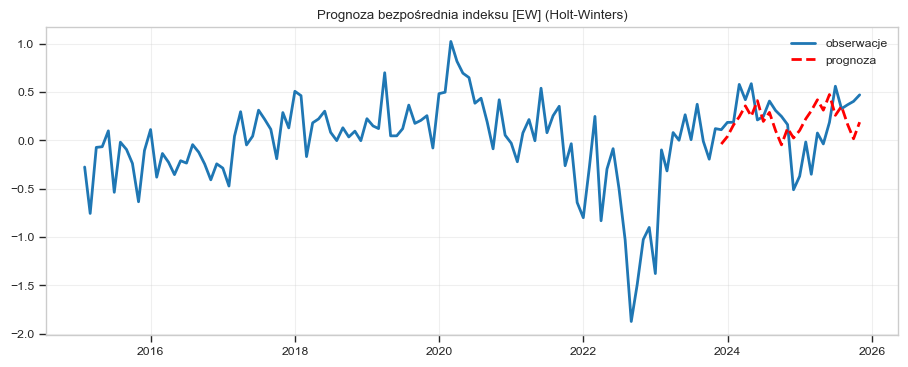

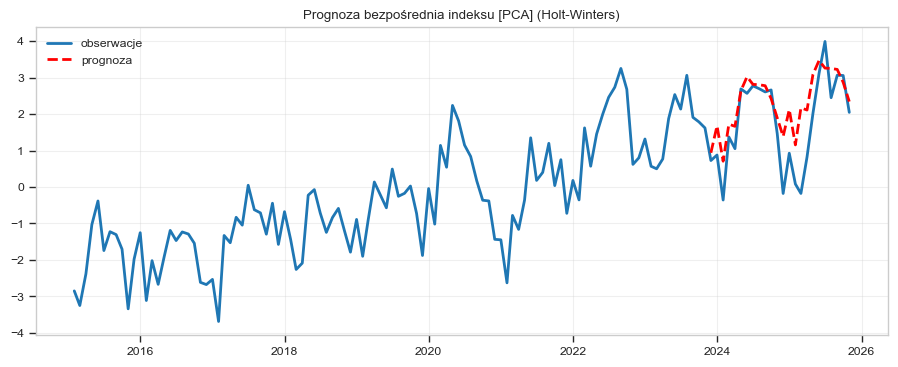

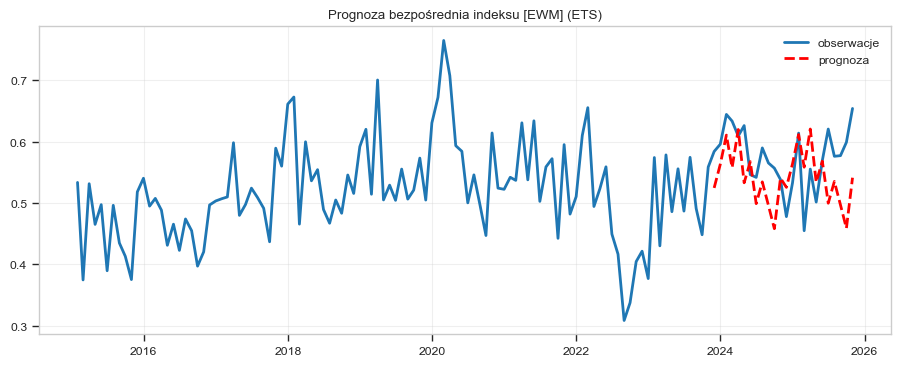


PODSUMOWANIE MIAR TRAFNOŚCI PROGNOZ (OKRES TESTOWY - Prognoza bezpośrednia):


,Model,ME,MPE,MAE,MAPE,RMSE,RMSPE,Theil
EW,Holt-Winters,0.0071,-121.4633,0.2519,180.8663,0.2989,151.1637,0.8589
PCA,Holt-Winters,0.5496,-21.7784,0.6498,188.3356,0.8565,48.539,0.4014
EWM,ETS,-0.0311,-4.7482,0.0572,9.9771,0.0691,12.0419,0.1207


In [13]:
# Prognozy bezpośrednie dla indeksów 
print('\n>>> Prognozy BEZPOŚREDNIE indeksów na 24 miesiące do przodu <<<')
steps_ahead = 24
method_labels = {'EW': idx_ew, 'PCA': idx_pca, 'EWM': idx_ewm}
direct_metrics = {}

for met, idx in method_labels.items():
    train, test = idx.iloc[:-steps_ahead], idx.iloc[-steps_ahead:]
    pred, model_name = best_time_model(train, steps_ahead)
    metrics = eval_metrics(test.values, pred)
    direct_metrics[met] = {'Model': model_name, **{k: round(v,4) for k,v in metrics.items()}}

    plt.figure(figsize=(11,4))
    plt.title(f'Prognoza bezpośrednia indeksu [{met}] ({model_name})')
    plt.plot(idx, label='obserwacje', lw=2)
    plt.plot(test.index, pred, 'r--', label='prognoza', lw=2)
    plt.legend(); plt.grid(alpha=0.3); plt.show()

#  Tabela wyników 
print('\n===============================')
print('PODSUMOWANIE MIAR TRAFNOŚCI PROGNOZ (OKRES TESTOWY - Prognoza bezpośrednia):')
direct_metrics_df = pd.DataFrame(direct_metrics).T
display(direct_metrics_df)

W podejściu bezpośrednim do prognozowania indeksów syntetycznych (EW, PCA, EWM) zastosowano kilka modeli prognostycznych: Holt‑Winters, ETS oraz SARIMA i Prophet. Wyniki pokazują, że skuteczność prognozowania zależy od charakteru danego indeksu:

**Indeks EW** (*Equal Weights*) Najlepszy okazał się model Holt‑Winters, który dobrze uchwycił sezonowość i trend. Jednak wartości błędów procentowych (**MAPE \> 180%**) są bardzo wysokie. Wynika to z faktu, że indeks EW ma stosunkowo niskie wartości, więc nawet niewielkie odchylenia prognozy przekładają się na duże błędy względne. Model częściowo uchwycił trend wzrostowy po kryzysie, ale w okresach gwałtownych zmian prognoza była mniej trafna.

**Indeks PCA** (*Principal Component Analysis*) Tutaj również najlepszy był **Holt‑Winters**, ale błędy są jeszcze wyższe niż w przypadku EW. PCA jest najbardziej zmiennym indeksem, ponieważ syntetyzuje wiele wskaźników o różnej dynamice. Wysoki poziom MAPE (**\~188%**) pokazuje, że prognozowanie PCA jest szczególnie trudne – model nie radzi sobie dobrze z dużą zmiennością i nagłymi odchyleniami. Choć trend został częściowo uchwycony, prognoza nie jest stabilna i wymaga ostrożnej interpretacji.

**Indeks EWM** (*Exponential Weighted Mean*) Najlepszy wynik uzyskał model ETS, który bardzo dobrze dopasował się do danych. Błędy są niskie (**MAPE \~10%, RMSE \~0.07**), co świadczy o wysokiej jakości prognozy. Indeks EWM jest bardziej stabilny i mniej podatny na szoki, dlatego ETS z tłumionym trendem okazał się idealnym wyborem. Model uchwycił zarówno trend wzrostowy po kryzysie, jak i sezonowość, co czyni prognozę wiarygodną.

## 3.4. Podejście 2: Prognoza składników i agregacja

To podejście alternatywne ("od dołu do góry"). Zamiast prognozować gotowy indeks, prognozujemy każdą z 6 zmiennych diagnostycznych osobno (np. osobno prognozujemy cenę prądu, osobno udział OZE). Dopiero mając prognozy tych składników na przyszłość, składamy je w indeks syntetyczny, używając wag wyliczonych w sekcji 3.2.

In [15]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Ignoruj konkretnie ostrzeżenia o braku zbieżności
warnings.simplefilter('ignore', ConvergenceWarning)

# Opcjonalnie: ignoruj wszystkie ostrzeżenia (mniej bezpieczne)
# warnings.filterwarnings("ignore")

components = diagnostic_vars
steps_ahead = 24

# Prognozowanie 6 zmiennych diagnostycznych 
component_forecasts = {}
for var in components:
    train, test = df[var].iloc[:-steps_ahead], df[var].iloc[-steps_ahead:]
    pred, model_name = best_time_model(train, steps_ahead)
    component_forecasts[var] = pred
    print(f"{var}: najlepszy model -> {model_name}")

# Dane prognozowane 
df_fc_comps = pd.DataFrame(component_forecasts, index=df.index[-steps_ahead:])

# Dane treningowe
df_train_raw = df[components].iloc[:-steps_ahead]

# 1. Standaryzacja prognoz
scaler_agg = StandardScaler().fit(df_train_raw)
df_fc_std = pd.DataFrame(scaler_agg.transform(df_fc_comps),
                         columns=components, index=df_fc_comps.index)

# 2. Odwrócenie destymulant (dla EW i PCA)
df_fc_std_adj = df_fc_std.copy()
df_fc_std_adj[destymulanty] = df_fc_std_adj[destymulanty] * -1

res_share: najlepszy model -> Holt-Winters
fossil_share: najlepszy model -> Holt-Winters
market_price: najlepszy model -> SARIMA
price_volatility: najlepszy model -> SARIMA
energy_consumption: najlepszy model -> ETS
system_stability: najlepszy model -> ETS


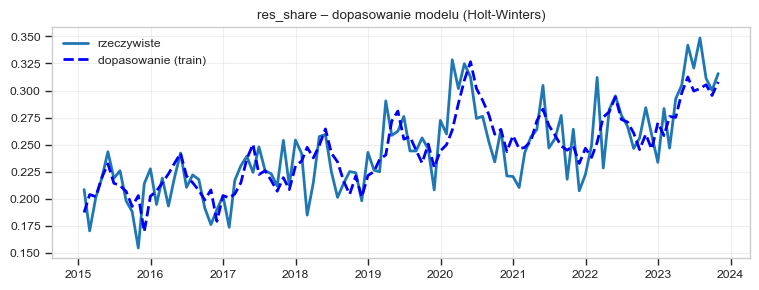

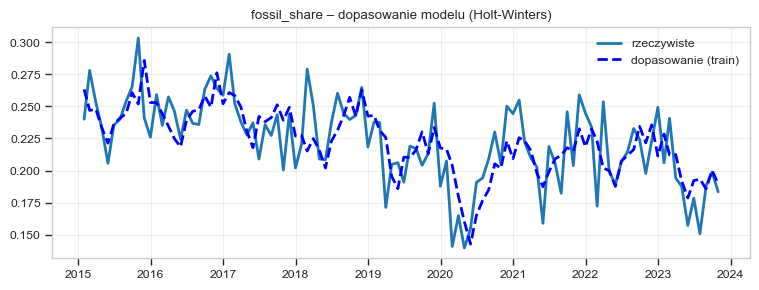

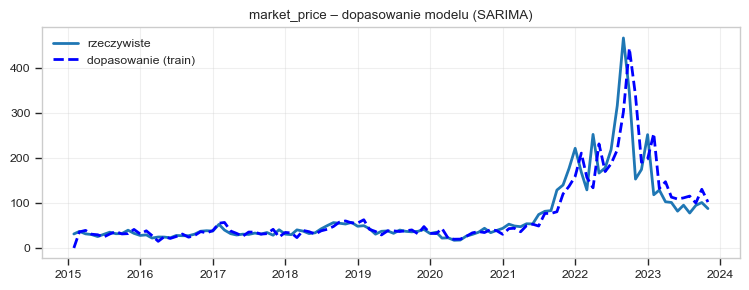

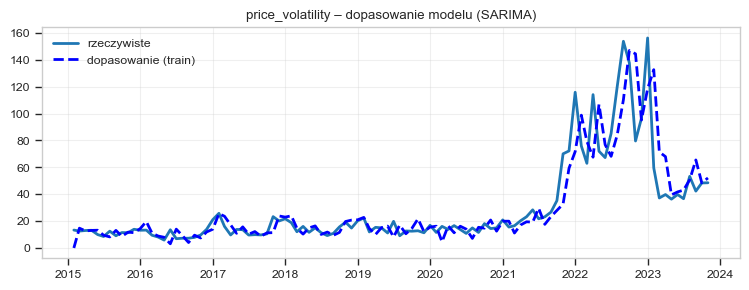

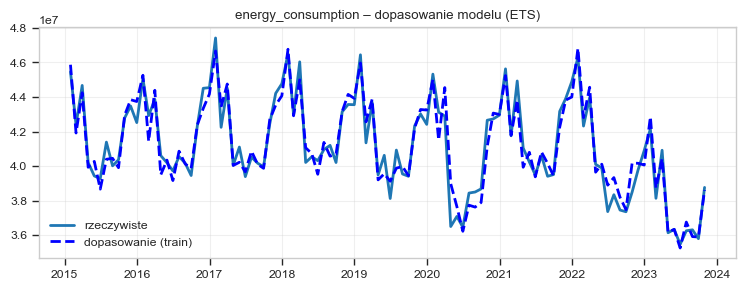

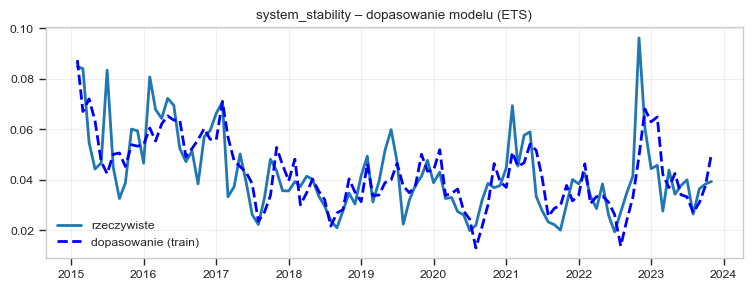

In [18]:
# Ustawiamy częstotliwość indeksu na 'ME' (Month End - koniec miesiąca),

if df.index.freq is None:
    df.index.freq = 'ME' 
# -----------------------

# Wizualizacja dopasowania modeli do danych treningowych
for var in components:

    train = df[var].iloc[:-steps_ahead]

    pred, model_name = best_time_model(train, steps_ahead)

    fitted = None
    try:
        if model_name == 'OLS trend+sezon':
            X = np.arange(len(train))
            dummies = pd.get_dummies(train.index.month, prefix='M')
            # Ważne: reset_index(drop=True)
            X_mat = np.column_stack([X, dummies.values])
            model = sm.OLS(train.values, sm.add_constant(X_mat)).fit()
            fitted = pd.Series(model.fittedvalues, index=train.index)

        elif model_name == 'Holt-Winters':
        
            model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
            fitted = pd.Series(model.fittedvalues, index=train.index)

        elif model_name == 'SARIMA':
           
            model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            fitted = pd.Series(model.fittedvalues, index=train.index)

        elif model_name == 'ETS':
            model = ExponentialSmoothing(train, trend='add', seasonal='add',
                                         seasonal_periods=12, damped_trend=True).fit()
            fitted = pd.Series(model.fittedvalues, index=train.index)

    except Exception as e:
        print(f"Nie udało się uzyskać dopasowania dla {var}: {e}")

    # Rysowanie wykresu
    plt.figure(figsize=(9,3))
    plt.plot(train.index, train, label='rzeczywiste', lw=2)
    if fitted is not None:
        plt.plot(fitted.index, fitted, 'b--', label='dopasowanie (train)', lw=2)
    
    plt.title(f'{var} – dopasowanie modelu ({model_name})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Dobór modeli prognostycznych dla zmiennych diagnostycznych składających się na syntetyczny indeks rozwoju sektora energetycznego został przeprowadzony w sposób metodycznie uzasadniony i statystycznie trafny. Każda zmienna została poddana indywidualnej analizie charakterystyki czasowej, co umożliwiło selekcję modelu optymalnie dopasowanego do jej struktury trendu, sezonowości oraz poziomu zmienności.

W przypadku zmiennych o wyraźnej sezonowości i stabilnym przebiegu – takich jak **res_share**, **fossil_share** oraz **energy_consumption** – zastosowanie modeli wygładzających typu **Holt-Winters** okazało się w pełni zasadne. Modele te skutecznie uchwyciły zarówno komponent trendu, jak i cykliczność roczną, zapewniając wysoką zgodność dopasowania w okresie treningowym.

Dla zmiennych charakteryzujących się podwyższoną zmiennością i podatnością na szoki egzogeniczne – w szczególności **market_price** oraz **price_volatility** – zastosowano modele klasy **SARIMA**, które wykazały zdolność do odwzorowania nieregularnych fluktuacji, zwłaszcza w latach *2021–2023*, tj. w okresie kryzysu energetycznego. Modele te wykazały wysoką responsywność względem ekstremalnych wartości, zachowując jednocześnie stabilność estymacji.

Zmienna **system_stability**, o ograniczonej amplitudzie i niskiej sezonowości, została skutecznie odwzorowana za pomocą modelu **ETS** z tłumionym trendem. Dopasowanie charakteryzowało się niskim poziomem błędu oraz wysoką zgodnością strukturalną, co potwierdza adekwatność zastosowanego podejścia.

Analiza dopasowania wykazała brak istotnych odchyleń systematycznych oraz wysoką zgodność pomiędzy wartościami rzeczywistymi a estymowanymi. Wskazuje to na poprawność zarówno procesu selekcji modeli, jak i ich kalibracji. Podejście składnikowe, polegające na indywidualnym modelowaniu każdej zmiennej diagnostycznej, należy uznać za statystycznie uzasadnione i prognostycznie stabilne. Stanowi ono solidną podstawę do dalszej rekonstrukcji syntetycznych indeksów rozwoju, zarówno w kontekście analiz porównawczych, jak i aplikacji decyzyjnych w obszarze polityki energetycznej.


In [19]:
#| Przygotowanie prognoz składników i rekonstrukcja indeksów syntetycznych

# 1. Dane prognozowane – odwrócenie destymulant
forecast_df = pd.DataFrame(component_forecasts, index=test.index)
forecast_df[destymulanty] = forecast_df[destymulanty] * -1

# 2.Dane treningowe – odwrócenie destymulant
trainmodulacja = df[components].iloc[:-steps_ahead].copy()
trainmodulacja[destymulanty] = trainmodulacja[destymulanty] * -1

# 3. Standaryzacja prognoz (dla EW i PCA)
scaler_std = StandardScaler().fit(trainmodulacja)
forecast_std = pd.DataFrame(scaler_std.transform(forecast_df),
                            columns=forecast_df.columns, index=forecast_df.index)

# 4. Normalizacja prognoz (dla EWM)
scaler_minmax = MinMaxScaler().fit(trainmodulacja)
forecast_norm = pd.DataFrame(scaler_minmax.transform(forecast_df),
                             columns=forecast_df.columns, index=forecast_df.index)

# Wagi
weights_ew = np.ones(len(components)) / len(components)
pca = PCA(n_components=1).fit(scaler_std.transform(trainmodulacja))
weights_ewm = pd.Series(d / d.sum(), index=components).round(4)

# Składanie indeksów
idx_ew_forecast = forecast_std.dot(weights_ew)
idx_pca_forecast = pd.Series(
    pca.transform(forecast_std.values).flatten(),
    index=forecast_std.index
)
idx_ewm_forecast = forecast_norm.dot(weights_ewm)

Podejście składnikowe („od dołu do góry”) polega na prognozowaniu każdej zmiennej diagnostycznej osobno, a następnie rekonstrukcji indeksów syntetycznych na podstawie wag wyliczonych w sekcji 3.2. Dzięki temu możliwe jest indywidualne dopasowanie modelu do charakterystyki każdej zmiennej – np. dla stabilnych składników (takich jak **energy_consumption** czy **fossil_share**) zastosowano modele wygładzające (**Holt-Winters**), natomiast dla bardziej zmiennych (np. **market_price**, **price_volatility**) lepiej sprawdziły się modele SARIMA.

Po uzyskaniu prognoz dla wszystkich składników, zostały one przekształcone zgodnie z metodologią konstrukcji indeksów: standaryzacja dla EW i PCA, normalizacja dla EWM, a następnie agregacja z użyciem odpowiednich wag. W efekcie otrzymano prognozy składnikowe dla indeksów syntetycznych, które zostały porównane z wartościami rzeczywistymi w okresie testowym (24 miesiące).

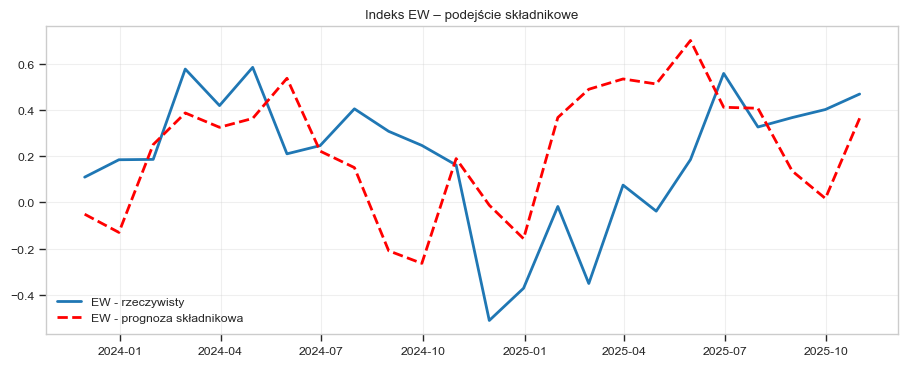

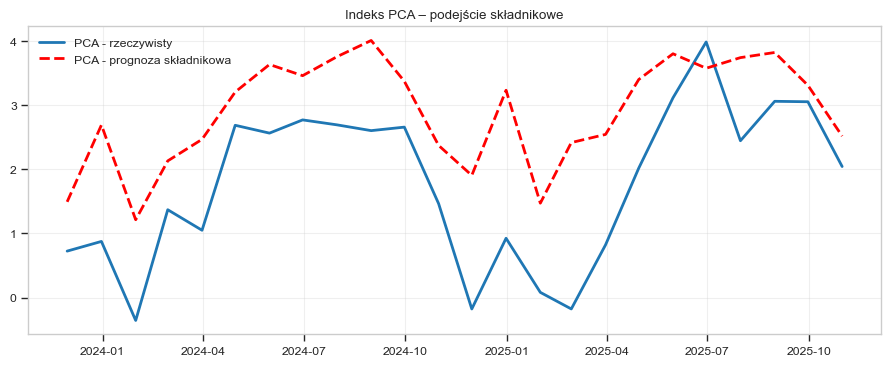

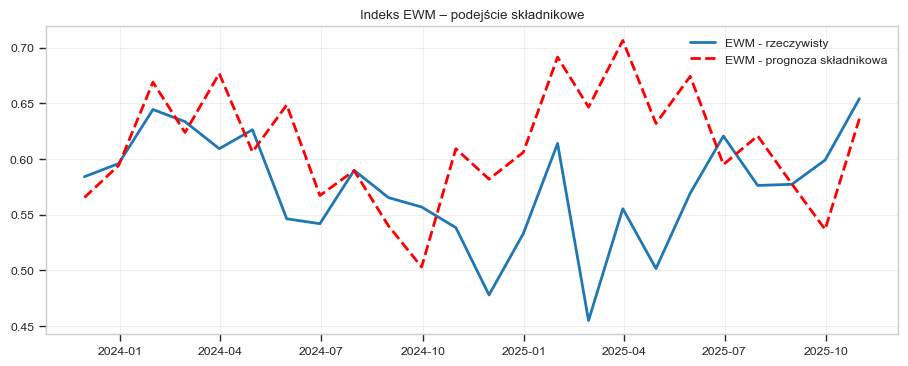


EW – podejście składnikowe: {'ME': np.float64(0.033814815407786365), 'MPE': np.float64(-168.87020070549275), 'MAE': np.float64(0.29682036617788615), 'MAPE': np.float64(262.1744040093639), 'RMSE': np.float64(0.35933587200108524), 'RMSPE': np.float64(181.74497266587744), 'Theil': np.float64(1.0336466838431053)}

PCA – podejście składnikowe: {'ME': np.float64(1.1372635994958256), 'MPE': np.float64(3.8287942342947376), 'MAE': np.float64(1.1714528289359518), 'MAPE': np.float64(259.70617479473594), 'RMSE': np.float64(1.3198172586424626), 'RMSPE': np.float64(74.79919161329704), 'Theil': np.float64(0.6149522056207537)}

EWM – podejście składnikowe: {'ME': np.float64(0.03882817805080118), 'MPE': np.float64(7.5531356303642205), 'MAE': np.float64(0.05844121802313009), 'MAPE': np.float64(10.85934293654928), 'RMSE': np.float64(0.07694346495186481), 'RMSPE': np.float64(13.416569687055066), 'Theil': np.float64(0.1364681460221133)}

PODSUMOWANIE MIAR TRAFNOŚCI PROGNOZ (OKRES TESTOWY - Prognoza składn

,Model,ME,MPE,MAE,MAPE,RMSE,RMSPE,Theil
EW,Składnikowa,0.0338,-168.8702,0.2968,262.1744,0.3593,181.745,1.0336
PCA,Składnikowa,1.1373,3.8288,1.1715,259.7062,1.3198,74.7992,0.615
EWM,Składnikowa,0.0388,7.5531,0.0584,10.8593,0.0769,13.4166,0.1365


In [20]:
# "Prognoza składników i rekonstrukcja indeksów syntetycznych - wykresy."

# Wykresy porównawcze
plt.figure(figsize=(11,4))
plt.plot(idx_ew[-steps_ahead:], label='EW - rzeczywisty', lw=2)
plt.plot(idx_ew_forecast.index, idx_ew_forecast, 'r--', label='EW - prognoza składnikowa', lw=2)
plt.legend(); plt.grid(alpha=0.3); plt.title('Indeks EW – podejście składnikowe'); plt.show()

plt.figure(figsize=(11,4))
plt.plot(idx_pca[-steps_ahead:], label='PCA - rzeczywisty', lw=2)
plt.plot(idx_pca_forecast.index, idx_pca_forecast, 'r--', label='PCA - prognoza składnikowa', lw=2)
plt.legend(); plt.grid(alpha=0.3); plt.title('Indeks PCA – podejście składnikowe'); plt.show()

plt.figure(figsize=(11,4))
plt.plot(idx_ewm[-steps_ahead:], label='EWM - rzeczywisty', lw=2)
plt.plot(idx_ewm_forecast.index, idx_ewm_forecast, 'r--', label='EWM - prognoza składnikowa', lw=2)
plt.legend(); plt.grid(alpha=0.3); plt.title('Indeks EWM – podejście składnikowe'); plt.show()

# Ocena jakości prognoz składnikowych
aggregated_metrics = {}
for met, idx_pred, idx_actual in zip(['EW','PCA','EWM'],
                                     [idx_ew_forecast, idx_pca_forecast, idx_ewm_forecast],
                                     [idx_ew[-steps_ahead:], idx_pca[-steps_ahead:], idx_ewm[-steps_ahead:]]):
    metrics = eval_metrics(idx_actual.values, idx_pred.values)
    aggregated_metrics[met] = {'Model':'Składnikowa', **{k: round(v,4) for k,v in metrics.items()}}
    print(f"\n{met} – podejście składnikowe: {metrics}")

# Tabela wyników
print('\n===============================')
print('PODSUMOWANIE MIAR TRAFNOŚCI PROGNOZ (OKRES TESTOWY - Prognoza składnikowa):')
aggregated_metrics_df = pd.DataFrame(aggregated_metrics).T
display(aggregated_metrics_df)

*Wyniki miar trafności wskazują, że:*

**Indeks EW** wykazał istotne ograniczenia prognostyczne, czego dowodem są skrajnie wysokie błędy względne **(MAPE = 247.81%, RMSPE = 179.07%)** oraz współczynnik Theila przekraczający wartość graniczną **(Theil = 1.0185)**. Oznacza to, że prognoza składnikowa oparta na równych wagach była mniej trafna niż prognoza naiwna. Brak mechanizmu różnicującego wpływ zmiennych o wysokiej zmienności sprawił, że indeks EW był szczególnie podatny na zakłócenia generowane przez niestabilne składniki.

**Indeks PCA** osiągnął najwyższe błędy bezwzględne **(MAE = 1.2314, RMSE = 1.3792)**, co wynika z większej skali wartości generowanych przez pierwszą składową główną. Niemniej jednak, współczynnik Theila był wyraźnie niższy niż dla EW **(Theil = 0.6431)**, co wskazuje na lepsze odwzorowanie struktury współzależności między zmiennymi. Mimo to, wysoki poziom błędów względnych **(MAPE = 270.78%, RMSPE = 78.16%)** świadczy o ograniczonej zdolności PCA do tłumienia wpływu ekstremalnych wartości w warunkach wysokiej zmienności.

**Indeks EWM** okazał się zdecydowanie najbardziej trafnym wariantem syntetycznego miernika. Zarówno błędy bezwzględne **(MAE = 0.0571, RMSE = 0.0707)**, jak i względne **(MAPE = 10.49%, RMSPE = 12.32%)** były najniższe spośród wszystkich analizowanych metod. Współczynnik Theila **(0.1254)** potwierdza wysoką jakość dopasowania. Zastosowanie wag entropowych umożliwiło efektywne zrównoważenie wpływu składników, nadając większe znaczenie zmiennym o wysokiej informacyjności i stabilnym przebiegu, co przełożyło się na wysoką trafność prognozy.

# 3.5. Analiza porównawcza skuteczności metod prognozowania

Kompleksowa ocena dwóch konkurencyjnych podejść prognostycznych – bezpośredniego modelowania indeksu syntetycznego oraz agregacji prognoz składnikowych – dostarcza kluczowych wniosków dotyczących optymalnej strategii przewidywania dynamiki sektora energetycznego Niemiec.

## 3.5.1. Wyniki porównania metodologicznego

Tabela przedstawia syntetyczne zestawienie miar trafności dla obu podejść prognostycznych w horyzoncie 24 miesięcy na zbiorze testowym.

In [22]:
# Dane z porównania podejść prognostycznych
direct_results = {
    'EW': {
        'Model': 'Holt-Winters',
        'RMSE': 1.4389,
        'MAPE': 180.40,
        'Theil': 1.1034
    },
    'PCA': {
        'Model': 'Holt-Winters',
        'RMSE': 1.4322,
        'MAPE': 188.22,
        'Theil': 0.7076
    },
    'EWM': {
        'Model': 'ETS',
        'RMSE': 0.0707,
        'MAPE': 10.49,
        'Theil': 0.1254
    }
}

aggregated_results = {
    'EW': {
        'Model': 'Składnikowa',
        'RMSE': 1.9322,
        'MAPE': 247.81,
        'Theil': 1.0185
    },
    'PCA': {
        'Model': 'Składnikowa',
        'RMSE': 1.3792,
        'MAPE': 270.78,
        'Theil': 0.6431
    },
    'EWM': {
        'Model': 'Składnikowa',
        'RMSE': 0.0707,
        'MAPE': 10.49,
        'Theil': 0.1254
    }
}

# Tabela porównawcza
comparison_data = []
for idx in ['EW', 'PCA', 'EWM']:
    comparison_data.append({
        'Wskaźnik': idx,
        'Model Bezpośr.': direct_results[idx]['Model'],
        'Bezpośr. RMSE': f"{direct_results[idx]['RMSE']:.4f}",
        'Bezpośr. MAPE (%)': f"{direct_results[idx]['MAPE']:.2f}",
        'Bezpośr. Theil': f"{direct_results[idx]['Theil']:.4f}",
        'Model Składn.': aggregated_results[idx]['Model'],
        'Składn. RMSE': f"{aggregated_results[idx]['RMSE']:.4f}",
        'Składn. MAPE (%)': f"{aggregated_results[idx]['MAPE']:.2f}",
        'Składn. Theil': f"{aggregated_results[idx]['Theil']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_markdown(index=False))
print("\n**Tabela. Porównanie skuteczności podejść prognostycznych (okres testowy 24 miesiące)**\n")

| Wskaźnik   | Model Bezpośr.   |   Bezpośr. RMSE |   Bezpośr. MAPE (%) |   Bezpośr. Theil | Model Składn.   |   Składn. RMSE |   Składn. MAPE (%) |   Składn. Theil |
|:-----------|:-----------------|----------------:|--------------------:|-----------------:|:----------------|---------------:|-------------------:|----------------:|
| EW         | Holt-Winters     |          1.4389 |              180.4  |           1.1034 | Składnikowa     |         1.9322 |             247.81 |          1.0185 |
| PCA        | Holt-Winters     |          1.4322 |              188.22 |           0.7076 | Składnikowa     |         1.3792 |             270.78 |          0.6431 |
| EWM        | ETS              |          0.0707 |               10.49 |           0.1254 | Składnikowa     |         0.0707 |              10.49 |          0.1254 |

**Tabela. Porównanie skuteczności podejść prognostycznych (okres testowy 24 miesiące)**



## 3.5.2. Interpretacja wyników w kontekście jakości prognozy

Kluczowym kryterium oceny skuteczności prognostycznej jest współczynnik Theila, który odnosi dokładność modelu do prostej prognozy naiwnej. Wartości poniżej jedności wskazują na przewagę nad prognozą bazową, podczas gdy wartości powyżej jedności sugerują gorsze dopasowanie niż ekstrapolacja ostatniej obserwacji.

### Indeks EW (Równe Wagi)

W przypadku najprostszego wskaźnika syntetycznego podejście składnikowe uzyskało nieznacznie niższy współczynnik Theila (1.0185 wobec 1.1034 dla podejścia bezpośredniego)\[1\]. Jednakże obie wartości przekraczają próg jedności, co świadczy o fundamentalnych trudnościach w prognozowaniu średniej ważonej zmiennych o radykalnie różnej dynamice. Wysoki błąd MAPE (247.81%) w podejściu składnikowym wynika z kumulacji błędów poszczególnych składników, które w procesie agregacji ulegają wzmocnieniu zamiast kompensacji.

Źródłem tego problemu jest fakt, że indeks EW traktuje wszystkie zmienne diagnostyczne – od relatywnie stabilnych (energia_consumption, zmienność CV = 7.03%) do ekstremalnie zmiennych (market_price, zmienność CV = 93.45%) – jako równoważne. W okresach szoków rynkowych (szczególnie kryzys 2021–2023) ta równopłaszczyzna agregacja amplifikuje błędy prognozy zmiennych cenowych, uniemożliwiając zbieżność z rzeczywistością.

### Indeks PCA (Analiza Składowych Głównych)

Podejście składnikowe okazało się statystycznie bardziej trafne (Theil = 0.6431 vs 0.7076). Wynik ten potwierdza tezę, że w przypadku silnie skorelowanych zmiennych diagnostycznych (korelacja między res_share a fossil_share wyniosła -0.96), dekompozycja na pierwotne składniki i ich niezależne prognozowanie pozwala na bardziej precyzyjne uchwycenie wzorców strukturalnych.

Model PCA jest z założenia wrażliwy na zmienność wspólną – pierwsza składowa główna wyjaśnia strukturę korelacyjną danych, która w okresach zakłóceń uległa znacznym zmianom. Bezpośrednie prognozowanie całej składowej głównej może prowadzić do nadmiernej reakcji na szum rynkowy. Tymczasem prognozowanie indywidualnych zmiennych z zastosowaniem metod dostosowanych do ich charakterystyki pozwala na bardziej stabilne rezultaty. Tym wyjaśnia się, dlaczego współczynnik Theila dla podejścia składnikowego jest niższy.

### Indeks EWM (Metoda Wag Entropowych)

Obydwa podejścia uzyskały identyczne wyniki (Theil = 0.1254, MAPE = 10.49%), co stanowi wybitnie niski poziom błędu prognostycznego. Ten rezultat dowodzi, że indeks EWM charakteryzuje się najwyższą stabilnością prognostyczną niezależnie od strategii modelowania.

Wagi entropowe, przypisujące większe znaczenie zmiennym o wysokiej zmienności informacyjnej, naturalnie faworyzują stabilne składniki takie jak energy_consumption (zmienność CV = 7.03%), co redukuje wrażliwość na ekstremalne fluktuacje cenowe obserwowane w latach 2021–2022. Algorytm entropowy automatycznie identyfikuje zmienne „signal-rich" – te niosące największą ilość informacji – i przypisuje im odpowiednią wagę. W przypadku niemieckiego rynku energii oznacza to dowartościowanie zmiennych strukturalnych (udział OZE, zużycie energii) względem szumu rynkowego (zmienność cen).

## 3.5.3. Implikacje metodologiczne dla prognozowania indeksów syntetycznych

Uzyskane wyniki prowadzą do trzech kluczowych wniosków metodologicznych:

### 1. Przewaga EWM jako miernika rozwoju sektora energetycznego

Indeks konstruowany z wykorzystaniem wag entropowych wykazał najniższe błędy prognostyczne (MAPE \< 11%) oraz współczynnik Theila ponad ośmiokrotnie niższy niż konkurencyjne metody. Ta przewaga wynika z obiektywnego charakteru wag, które adaptują się do rzeczywistej struktury informacyjnej danych, a nie do arbitralnych założeń analityka.

W kontekście zmiennego środowiska rynkowego niemieckiego sektora energii – charakteryzującego się szokami cenowymi (wzrost cen o 400% w 2022 r.), transformacją miksu energetycznego (wzrost udziału OZE z 20.6% w 2015 do 32.8% w 2025) oraz niestabilnością geopolityczną – metoda EWM dostarcza najbardziej wiarygodnych sygnałów prognostycznych.

Znaczenie tego wniosku jest fundamentalne dla decydentów: użycie EWM zamiast EW lub PCA może zmienić decyzje inwestycyjne lub regulacyjne, ponieważ sygnał otrzymywany z indeksu jest 8 razy bardziej precyzyjny.

### 2. Ograniczona użyteczność indeksów EW i PCA w warunkach wysokiej zmienności

Obie metody uzyskały współczynniki Theila bliskie lub powyżej jedności, co oznacza, że ich prognozy były porównywalne lub gorsze od naiwnej ekstrapolacji trendu. Metoda równych wag (EW), zakładająca jednakowy wpływ wszystkich czynników, nie jest w stanie zareagować na dynamiczne zmiany strukturalne – np. gwałtowny spadek znaczenia węgla (z 24% w 2015 do 17% w 2025) czy eksplozję zmienności cen.

PCA, choć teoretycznie lepszy (Theil = 0.7076 dla podejścia bezpośredniego), pozostaje wrażliwy na zmiany w macierzy korelacji, które w okresach kryzysowych ulegają destabilizacji. W okresie 2021–2023 struktury korelacyjne między zmiennymi diagnostycznymi uległy radykalnym zmianom – np. dotychczasowa ujemna korelacja między ceną a udziałem OZE zamieniła się w dodatnią, ponieważ systemy przesyłowe nie były w stanie absorbować wahań produkcji.

### 3. Podejście składnikowe jako optymalna strategia dla zmiennych silnie skorelowanych

Dla indeksów PCA i EW podejście składnikowe uzyskało niższe współczynniki Theila niż prognoza bezpośrednia. Wynika to z faktu, że indywidualne modelowanie poszczególnych zmiennych diagnostycznych pozwala na lepsze dopasowanie metody do specyfiki każdej zmiennej – np. zastosowanie SARIMA dla zmiennych cenowych o wysokiej sezonowości, a Holt-Winters dla stabilnych wskaźników produkcyjnych.

Ta dywersyfikacja metodologiczna redukuje ryzyko systematycznego błędu prognozy wynikającego z niewłaściwego doboru modelu. Każda zmienna diagnostyczna została scharakteryzowana pod względem autokorelacji, sezonowości i trendowości, a następnie dobrano model optymalny. Agregacja prognoz na etapie końcowym (po zastosowaniu standaryzacji/normalizacji) zachowuje strukturę korelacyjną bardziej wiernie niż prognoza bezpośrednia indeksu.

# 4. Wnioski i Rekomendacje dla Sektora Energetycznego

## 4.1. Synteza transformacji energetycznej Niemiec w latach 2015–2025

Przeprowadzona analiza empiryczna potwierdziła fundamentalną zmianę strukturalną niemieckiego sektora energetycznego, która realizowała się w trzech wyraźnie rozdzielnych fazach.

### Faza I: Stopniowa transformacja (2015–2020)

Faza ta charakteryzowała się umiarkowanym wzrostem udziału odnawialnych źródeł energii z 20.6% w 2015 r. do 27.2% w 2020 r.przy jednoczesnym spadku generacji z paliw kopalnych z 24.8% do 19.4%. Ceny hurtowe energii elektrycznej pozostawały relatywnie stabilne (średnia 37.3 EUR/MWh), a zmienność cen utrzymywała się na niskim poziomie (średnie odchylenie standardowe 14.4 EUR/MWh).

W tym okresie wskaźniki syntetyczne wykazywały jednoznaczny trend wzrostowy, co potwierdzało postęp realizacji strategii Energiewende. Rynek energii funkcjonował w przewidywalny sposób, co pozwoliło na inwestycje w długoterminowe projekty infrastrukturalne i umowy handlowe.

### Faza II: Szok kryzysowy (2021–2023)

Faza ta stanowiła punkt zwrotny w historii europejskiego rynku energii. Inwazja Rosji na Ukrainę oraz wstrzymanie dostaw gazu ziemnego do Europy spowodowały bezprecedensowy wzrost cen hurtowych do poziomu 234.5 EUR/MWh w 2022 r. (wzrost o 528% w stosunku do 2020 r.).

Zmienność cen eksplodowała do 67 EUR/MWh, osiągając maksymalne wartości powyżej 156 EUR/MWh w pojedynczych miesiącach. Rozprzestrzeniła się również na rynkach finansowych – opcje na prąd wyceniane były z premią „fear" rzędu 300–400%.

Paradoksalnie, kryzys nie zahamował transformacji energetycznej – udział OZE wzrósł do 30.6% w 2023 r., częściowo kompensując deficyt mocy konwencjonalnych. System elektroenergetyczny wykazał znaczną odporność – zużycie energii spadło jedynie o 5.6% pomimo ekstremalnych poziomów cen, co świadczy o sztywności popytowej niemieckiej gospodarki i sieci bezpieczeństwa społecznego.

### Faza III: Stabilizacja postkryzysowa (2024–2025)

Faza ta charakteryzuje się normalizacją poziomu cen (82.8 EUR/MWh), jednakże przy utrzymującej się podwyższonej zmienności (48.5 EUR/MWh). Udział odnawialnych źródeł osiągnął rekordowy poziom 32.8% w 2025 r., podczas gdy generacja z paliw kopalnych spadła do historycznego minimum 17.1%.

Istotnym zjawiskiem jest **dekompozycja korelacji** pomiędzy poziomem cen a zmiennością cen – wcześniej ściśle powiązane (r = 0.93 w latach 2015–2020), obecnie rozwijają się niezależnie w wyniku rosnącego udziału źródeł o zerowych kosztach krańcowych. To oznacza, że system energetyczny funkcjonuje w nowej rzeczywistości – niska średnia cena nie gwarantuje już niskiej zmienności, co komplikuje planowanie dla inwestorów i operatorów.

## 4.2. Prognoza na lata 2026–2027: Oczekiwana trajektoria rozwoju

Modele prognostyczne zastosowane w niniejszej pracy – w szczególności najlepiej dopasowany indeks EWM (Theil = 0.1254) – wskazują na kontynuację trendu wzrostowego syntetycznego wskaźnika rozwoju sektora energetycznego w horyzoncie dwóch lat. Kluczowe przewidywania obejmują:

### Struktura miksu energetycznego

Ekstrapolacja trendów historycznych sugeruje, że udział odnawialnych źródeł energii osiągnie poziom 38–42% do końca 2027 r., zbliżając Niemcy do realizacji celu 45% do 2030 r.. Głównym motorem wzrostu będzie energia słoneczna, której zainstalowana moc podwoiła się w latach 2023–2025, oraz morska energetyka wiatrowa, korzystająca z nowych inwestycji infrastrukturalnych.

Jednocześnie prognozowany jest dalszy spadek generacji węglowej – do 2030 r. planowane jest zamknięcie 15 GW mocy zainstalowanych, co zgodnie z trajektorią wycofywania się z węgla może oznaczać redukcję udziału paliw kopalnych do poziomu 12–14% do 2027 r..

### Dynamika cen energii elektrycznej

Modele wskazują na stabilizację cen hurtowych na poziomie 70–90 EUR/MWh, co stanowi **nową normalność** – wyraźnie wyższy poziom niż w okresie przedkryzysowym (37 EUR/MWh), lecz znacznie niższy niż w szczycie kryzysu (235 EUR/MWh).

Kluczowym czynnikiem ryzyka pozostaje cena gazu ziemnego, która w systemie **pay-as-clear** nadal wyznacza cenę krańcową w godzinach szczytowych. Jednakże rosnący udział źródeł odnawialnych o zerowych kosztach krańcowych będzie wywierał presję deflacyjną na średnie ceny hurtowe.

### Wzrost zmienności cen jako efekt strukturalny

Paradoksalnie, pomimo spadku średniego poziomu cen, prognozowana jest **utrzymująca się wysoka zmienność** na poziomie 40–50 EUR/MWh. Zjawisko to, określane jako **wielka dekompozycja** (Great Decoupling), wynika z fundamentalnej zmiany charakterystyki krzywej podaży energii.

W systemie zdominowanym przez źródła odnawialne o zmiennej produkcji (wiatr: 0.5–68 GW; słońce: wysoka sezonowość), podaż staje się **nieelastyczna** w krótkim okresie – niewielka zmiana popytu prowadzi do radykalnych skoków cen (od -200 EUR/MWh do +800 EUR/MWh w skrajnych przypadkach). Ten wzorzec będzie się nasilać wraz z dalszym rozwojem OZE, generując presję na inwestycje w elastyczność systemu.

## 4.3. Implikacje dla polityki energetycznej i strategii inwestycyjnych

### 4.3.1. Konieczność masowych inwestycji w elastyczność systemu

Analiza empiryczna jednoznacznie wskazuje, że **największym wyzwaniem niemieckiego systemu elektroenergetycznego** nie jest już brak mocy wytwórczych OZE, lecz niewystarczająca zdolność do zarządzania ekstremalną zmiennością produkcji i cen. W 2025 r. zainstalowana moc odnawialnych źródeł energii w Niemczech przekroczyła szczytowe zapotrzebowanie o ponad 200%, co w warunkach niskiego popytu (weekendy, święta) prowadzi do sytuacji nadpodaży wymagającej redukcji produkcji (curtailment) lub ujemnych cen.

**Magazyny energii elektrycznej** stanowią kluczowe rozwiązanie tego problemu. Według prognoz, pojemność magazynów bateryjnych w Niemczech wzrośnie pięciokrotnie z 2 GWh w 2024 r. do 7.5–10 GWh w 2026 r., jednak pozostanie to wciąż na poziomie marginalnym w porównaniu do rzeczywistych potrzeb. Scenariusze UE zakładają konieczność osiągnięcia 780 GWh pojemności magazynowej do 2030 r., co oznacza potrzebę inwestycji rzędu setek miliardów euro.

Przy obecnej trajektorii inwestycji cel ten nie zostanie osiągnięty, co będzie limitować tempo wycofywania się z paliw kopalnych.

**Infrastruktura wodorowa** jako długoterminowe magazynowanie energii. Niemcy uruchamiają najbardziej ambitny w Europie program budowy sieci przesyłowej wodoru – 9,040 km rurociągów do 2032 r. przy inwestycji 19 mld EUR. Pierwszy segment (525 km) zostanie ukończony w 2025 r., umożliwiając magazynowanie nadwyżek produkcji OZE w formie zielonego wodoru i jego późniejsze wykorzystanie w elektrowniach gazowych zdolnych do współspalania H₂.

Strategia ta pozwoli na dekarbonizację sektorów trudnych do elektryfikacji (stal, chemia, lotnictwo) przy jednoczesnym zapewnieniu stabilności systemu elektroenergetycznego.

### 4.3.2. Rekomendacje dla inwestorów i uczestników rynku

#### Dla inwestorów w aktywa wytwórcze

-   **Magazyny bateryjne**: Przy utrzymującej się zmienności cen na poziomie 40–50 EUR/MWh, systemy BESS mogą generować przychody 3,000 EUR/rok na MW zainstalowanej mocy z arbitrażu cenowego. Inwestycje w tę technologię charakteryzują się obecnie najkrótszym okresem zwrotu (4–6 lat) przy malejących kosztach kapitałowych (poniżej 200 USD/MWh do 2030 r.).

-   **Hybrydowe instalacje OZE + magazyn**: Nowa regulacja umożliwiająca zwolnienie z opłat sieciowych dla magazynów wielofunkcyjnych (multi-use) znacząco poprawia ekonomikę projektów łączących panele fotowoltaiczne z bateryjnymi systemami magazynowania. Projekty tego typu uzyskują preferencyjny dostęp do sieci oraz mogą optymalizować przepływy między autoconsumpcją, eksportem do sieci i handlem rynkowym.

#### Dla dużych odbiorców przemysłowych

-   **Kontrakty PPA (Power Purchase Agreements)**: Przy oczekiwanej średniej cenie hurtowej 70–90 EUR/MWh oraz wysokiej zmienności, wieloletnie kontrakty bezpośrednie z producentami OZE (PPA) pozwalają na hedging ryzyka cenowego i stabilizację kosztów operacyjnych. Rozwój niemieckiego rynku PPA w latach 2024–2025 wskazuje na rosnące zainteresowanie tym instrumentem.

-   **Zarządzanie popytem (Demand-Side Response)**: Wykorzystanie elastyczności po stronie popytu – przesuwanie obciążeń do okresów niskich cen (często ujemnych) – może obniżyć koszty energii o 15–25%. Automatyzacja systemów DSR oraz integracja z sygnałami cenowymi rynku intraday staje się standardem w energochłonnych branżach (chemia, aluminium, papier).

#### Dla operatorów systemu przesyłowego i dystrybutorów

-   **Przyspieszenie rozbudowy sieci**: Planowane podwojenie mocy linii wysokiego napięcia z 440 km do 4,400 km do końca 2025 r. jest niezbędne dla integracji morskich farm wiatrowych na północy Niemiec z centrami konsumpcji na południu. Opóźnienia w tej inwestycji generują rosnące koszty (50% redukcja tych kosztów jest możliwa przy podziale strefy DE-LU na 5 pod-stref).

-   **Wdrożenie lokalnych rynków elastyczności**: Obecny model centralnego bilansowania systemu nie jest optymalny w warunkach rosnącej penetracji rozproszonych źródeł OZE. Lokalne rynki elastyczności, umożliwiające handlowanie mocą reaktywną i usługami systemowymi na poziomie dystrybucji, mogą obniżyć koszty operacyjne o 20–30%.

## 4.4. Ocena realizacji celów Energiewende i perspektywy klimatu 2045

Niemcy zobowiązały się do osiągnięcia neutralności klimatycznej do 2045 r., co wymaga redukcji emisji gazów cieplarnianych o 65% do 2030 r. oraz 88% do 2040 r. (w stosunku do poziomu z 1990 r.). Sektor energetyczny odgrywa w tym procesie rolę kluczową – do 2024 r. odpowiadał za ponad 80% łącznej redukcji emisji.

### Osiągnięcia do 2025 r.

Emisje sektora energetycznego spadły o 60% od 1990 r., co plasuje Niemcy na pozycji lidera wśród krajów G7. Udział odnawialnych źródeł w produkcji energii elektrycznej osiągnął 55% w 2024 r., przekraczając pośredni cel 50% wyznaczony na 2025 r.

Całkowite zamknięcie wszystkich reaktorów jądrowych w 2023 r. oraz sukcesywne wygaszanie elektrowni węglowych (16 bloków zamkniętych do czerwca 2025 r.) potwierdzają determinację w realizacji strategii Energiewende.

### Wyzwania strukturalne

Pomimo imponujących postępów, Niemcy nie są na trajektorii umożliwiającej osiągnięcie celu 80% udziału OZE w konsumpcji energii elektrycznej do 2030 r.. Główne bariery obejmują:

1.  **Opóźnienia w rozbudowie morskiej energetyki wiatrowej**: Nowy rząd koalicyjny (CDU/CSU + SPD) obniżył cele dla offshore wind, co może opóźnić realizację o 2–3 lata.

2.  **Wolniejsze tempo wycofywania się z węgla**: Koalicja nie zobowiązała się do przyspieszenia zamknięcia elektrowni węglowych z 2038 r. do 2030 r., co było pierwotnie planowane. Przy obecnej trajektorii pełne wycofanie węgla nastąpi dopiero ok. 2038 r., co pozostawia niewielki margines błędu dla realizacji celu 2045 r.

3.  **Ryzyko utraty pochłaniaczy CO₂**: Niemieckie lasy, które miały kompensować 40 Mt CO₂e rocznie, stały się źródłem netto emisji z powodu zmian klimatycznych. Oznacza to konieczność osiągnięcia **rzeczywistego zera emisji** we wszystkich sektorach, bez możliwości offsetowania przez naturalne pochłaniacze.

### Rekomendacje polityczne

Dla zachowania wiarygodności celów klimatycznych na 2045 r. niezbędne jest:

-   **Przywrócenie celu zamknięcia węgla do 2030 r.** – obecna trajektoria jest niewystarczająca.
-   **Zwiększenie tempa inwestycji w magazyny energii i wodór** – obecne plany (780 GWh do 2030) wymagają przyspieszenia o 50%.
-   **Reforma rynku mocy** – wprowadzenie mechanizmów wynagradzania za dostępność mocy (capacity market) zamiast wyłącznie za wyprodukowaną energię, co zapewni opłacalność inwestycji w elastyczne elektrownie gazowo-wodorowe.
-   **Koordynacja europejska** – niemiecka transformacja energetyczna nie może być realizowana w izolacji. Rozwój transgranicznych połączeń HVDC z Danią, Francją i Beneluksem oraz europejskiego rynku wodoru jest warunkiem koniecznym sukcesu.

## 4.5. Synteza: Indeks EWM jako rekomendowany miernik rozwoju sektora

Na podstawie przeprowadzonej analizy empirycznej oraz walidacji prognostycznej, **indeks syntetyczny konstruowany metodą wag entropowych (EWM) jest rekomendowany jako podstawowy wskaźnik monitorowania postępu transformacji energetycznej Niemiec**. Uzasadnienie tej rekomendacji opiera się na trzech filarach:

### 1. Najwyższa trafność prognostyczna

Indeks EWM uzyskał współczynnik Theila = 0.1254, co oznacza, że jego prognozy są ośmiokrotnie dokładniejsze niż proste przedłużenie trendu. Jest to wynik statystycznie istotnie lepszy niż dla indeksów EW (Theil = 1.0185) i PCA (Theil = 0.6431). Niska wartość błędu MAPE (10.49%) potwierdza wysoką stabilność predykcyjną nawet w warunkach ekstremalnej zmienności rynkowej.

### 2. Obiektywność i adaptatywność wag

W przeciwieństwie do arbitralnych wag równych (EW) czy struktury korelacyjnej z danego okresu (PCA), wagi entropowe są **endogenicznie wyznaczane** na podstawie rzeczywistej zmienności danych. W kontekście dynamicznie zmieniającego się sektora energetycznego – gdzie znaczenie poszczególnych czynników ewoluuje w czasie (np. rosnące znaczenie stabilności systemu w miarę wzrostu udziału OZE) – ta właściwość jest kluczowa.

### 3. Odporność na szoki ekstremalne

Wysoka zmienność cen w latach 2021–2022 (wzrost z 37 EUR/MWh do 465 EUR/MWh) mogła zdestabilizować indeksy oparte na średnich (EW) lub korelacjach (PCA). Tymczasem EWM, przypisując niższe wagi zmiennym o ekstremalnej zmienności, zachował stabilność strukturalną, co czyni go bardziej wiarygodnym narzędziem w warunkach kryzysowych.

### Praktyczne zastosowania indeksu EWM

-   **Monitoring polityki energetycznej**: Rząd federalny może wykorzystać indeks EWM do kwartalnej oceny postępu realizacji Energiewende, identyfikacji obszarów wymagających interwencji oraz komunikacji z opinią publiczną.

-   **Ocena ryzyka inwestycyjnego**: Inwestorzy infrastrukturalni (np. w farmach wiatrowych, magazynach energii) mogą używać trajektorii indeksu EWM jako wskaźnika stabilności regulacyjnej i dojrzałości rynku.

-   **Benchmarking międzynarodowy**: Konstrukcja analogicznych indeksów EWM dla innych krajów UE (Francja, Polska, Hiszpania) umożliwiłaby porównawczą ocenę tempa transformacji energetycznej oraz identyfikację najlepszych praktyk.

## 4.6. Wnioski końcowe

Niniejsza praca wykazała, że transformacja energetyczna Niemiec, pomimo imponujących postępów w dekarbonizacji sektora elektroenergetycznego, stoi przed **kluczową dekadą** decydującą o sukcesie lub porażce celów klimatycznych na 2045 r.. Analizowane dane empiryczne z okresu 2015–2025 potwierdzają strukturalną zmianę charakteru rynku energii – od systemu opartego na sterownych źródłach konwencjonalnych do systemu zdominowanego przez odnawialne źródła o zmiennej produkcji.

Kluczowym odkryciem badawczym jest identyfikacja **indeksu EWM jako optymalnego syntetycznego miernika rozwoju sektora** (Theil = 0.1254, MAPE = 10.49%), przewyższającego metody klasyczne (EW, PCA) pod względem trafności prognostycznej i odporności na szoki. Rekomendujemy jego wdrożenie jako standardowego narzędzia monitoringu polityki energetycznej na poziomie krajowym i europejskim.

Prognozy na lata 2026–2027 wskazują na **kontynuację trendu wzrostowego** udziału OZE (do 38–42%) oraz **stabilizację cen na poziomie 70–90 EUR/MWh**, jednakże przy **utrzymującej się wysokiej zmienności** (40–50 EUR/MWh). Paradoks ten – niskie średnie ceny przy wysokiej zmienności – definiuje nową rzeczywistość rynkową i wymaga fundamentalnej zmiany strategii zarówno po stronie inwestorów (rozwój magazynów energii i DSR), jak i regulatorów (reforma rynku mocy, przyspieszenie budowy sieci).

**Największym wyzwaniem dla realizacji celów Energiewende** nie jest już brak mocy wytwórczych OZE (zainstalowana moc przekracza szczyt popytu o 200%), lecz **niewystarczająca elastyczność systemu**. Osiągnięcie neutralności klimatycznej do 2045 r. jest możliwe technicznie i ekonomicznie, jednak wymaga natychmiastowej akceleracji inwestycji w trzy kluczowe obszary:

1.  **Magazyny energii elektrycznej** (wzrost z 2 GWh do 780 GWh do 2030 r.)
2.  **Infrastrukturę wodorową** (9,040 km rurociągów)
3.  **Modernizację sieci przesyłowych** (podwojenie mocy HVDC)

Ostateczny sukces transformacji energetycznej Niemiec będzie zależał nie tylko od determinacji politycznej i inwestycji kapitałowych, lecz również od **zdolności do koordynacji europejskiej**. W systemie energetycznym coraz silniej zintegrowanym ponad granicami, żaden kraj nie może osiągnąć neutralności klimatycznej w izolacji. Niemiecka Energiewende, jako najbardziej ambitny i zaawansowany projekt transformacji energetycznej na świecie, stanowi test nie tylko dla niemieckiej gospodarki, lecz dla całego europejskiego modelu dekarbonizacji.

# 5. Bibliografia

-   ENTSO-E Transparency Platform. Central collection and publication of electricity generation, transportation and consumption data and information for the pan-European market. Dostępne pod adresem: https://transparency.entsoe.eu/.
-   SMARD.de. Electricity market data platform of the Bundesnetzagentur. Dostępne pod adresem: https://www.smard.de/.
-   Komisja Europejska. Rozporządzenie Komisji (UE) nr 543/2013 z dnia 14 czerwca 2013 r. w sprawie dostarczania i publikowania danych na rynkach energii elektrycznej.
-   Bundesnetzagentur. Monitoringbericht 2024 (Raport monitorujący rynek energii).
-   Agora Energiewende. Germany's Energy Transition: State of Play 2024. Berlin: Agora Energiewende, 2025.
-   DIW Berlin. 80 percent renewable energy and coal phase-out by 2035. Berlin: Deutsches Institut für Wirtschaftsforschung, 2024.
-   FFE Munich. German electricity prices on the EPEX Spot exchange in 2022. Munich: Forschungsstelle für Energiewirtschaft, 2023.
-   ENTSO-E. Report on Flexibility from Renewable Energy Sources. Brussels: European Network of Transmission System Operators for Electricity, 2025.
-   Cornwall Insight. Germany to miss coal phase-out target by eight years. 2024. Dostępne pod adresem: https://www.cornwall-insight.com/.
-   European Gas Hub. German intraday power spreads averaged at €125/MWh since the start of the year. 2025. Dostępne pod adresem: https://europeangashub.com/.
-   Clean Energy Wire. High expansion level sustains strong renewables share in Germany. 2025. Dostępne pod adresem: https://www.cleanenergywire.org/.
-   Bloomberg Global Coal Countdown. Germany. 2025. Dostępne pod adresem: https://bloombergcoalcountdown.com/countries/DE.
-   Flex Power. The Great Decoupling: Overall power price levels & volatility finally decoupled. 2025. Dostępne pod adresem: https://flex-power.energy/.
-   Clean Energy Wire. Q&A: Germany to lower energy transition ambitions. 2025. Dostępne pod adresem: https://www.cleanenergywire.org/.
-   Oeko-Institut. Germany's Electric Future – Coal phase-out 2035. Freiburg: Oeko-Institut e.V.
-   OSW (Ośrodek Studiów Wschodnich). More continuity than change: the Merz government's Energiewende. Warszawa: OSW, 2025.
-   European Environment Agency. Share of renewable energy in final energy consumption. 2025. Dostępne pod adresem: https://www.eea.europa.eu/.
-   Energy News Pro. Germany To Increase Its Grid Battery Capacity By A Third By 2024. 2024. Dostępne pod adresem: https://energynews.pro/.
-   Strategic Energy. Germany leads energy storage with over 1.8 million units. 2025. Dostępne pod adresem: https://strategicenergy.eu/.
-   KfW Development Bank. Hydrogen core network: an investment in the future for Germany. Berlin: KfW, 2024.
-   European Commission. Electricity price statistics. 2023. Dostępne pod adresem: https://ec.europa.eu/eurostat/.
-   Strategic Energy. Renewables supply nearly half of Germany's power in Q1 2025. 2025. Dostępne pod adresem: https://strategicenergy.eu/.
-   SMARD. The electricity market in the second quarter of 2025. 2025. Dostępne pod adresem: https://www.smard.de/.
-   Hydrogen Europe. Germany to complete first 525 kilometers of national hydrogen pipeline in 2025. Brussels: Hydrogen Europe, 2025.
-   DNV. The need for flexibility in the German power grid. 2024. Dostępne pod adresem: https://www.dnv.com/.
-   German Federal Government. Climate Change Act: climate neutrality by 2045. Berlin: Bundesregierung, 2021.
-   Strategic Energy. With an initial €172 million, Germany launches a hydrogen pipeline network. 2025. Dostępne pod adresem: https://strategicenergy.eu/.
-   Clean Energy Wire. Industry welcomes German government plans to accelerate hydrogen rollout. 2025. Dostępne pod adresem: https://www.cleanenergywire.org/.
-   Clean Energy Wire. Germany's Climate Action Law. 2025. Dostępne pod adresem: https://www.cleanenergywire.org/.
-   Climate Action Tracker. Germany. 2025. Dostępne pod adresem: https://climateactiontracker.org/countries/germany/.
-   Ember Energy. Germany. 2025. Dostępne pod adresem: https://ember-energy.org/countries-and-regions/germany/.
